# **Recall App — VisionAnalyzer Eval & Fine-tune**

**Goal:** Compare Apple VisionAnalyzer heuristic (baseline) against a fine-tuned T5 seq2seq model  
**Task:** Given raw OCR tokens from a parking image → predict the correct smart label  
**Dataset:** 45 real images captured with Recall app, OCR tokens extracted via `VNRecognizeTextRequest`  
**Baseline accuracy:** 15.6% exact match (7/45)

### Failure modes we're targeting
1. **Suffix stripping** — heuristic gets `P1` but misses the row letter, true label is `P1 I`  
2. **Noise pollution** — adjacent car plates / signs bleed into the label  
3. **No OCR fallback** — 8 images return empty tokens, heuristic defaults to `Memory`


In [1]:
!pip install transformers datasets sentencepiece -q

In [2]:
import json, random, re, csv
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

LOG_PATH    = '/content/drive/MyDrive/Recall_Parking/vision_log.json'
LABELS_PATH = '/content/drive/MyDrive/Recall_Parking/labels.csv'

with open(LOG_PATH) as f:
    vision_log = json.load(f)

# batch runner fired multiple times — one entry per image
vision_log = vision_log[:51]

labels = {}
with open(LABELS_PATH) as f:
    for row in csv.DictReader(f):
        image_id  = row['image_id'].strip()
        true_label = row['true_label'].strip()
        if true_label.lower() not in ('<null>', 'null', ''):
            labels[image_id] = true_label

HEURISTIC_LABELS = {
    'park_001': 'Memory', 'park_002': 'TO TH', 'park_003': 'Parking · D04',
    'park_004': 'Parking · D6', 'park_005': 'Parking · P6', 'park_006': '00',
    'park_007': 'Parking · B2', 'park_008': 'Parking · LEVEL ALBL', 'park_009': '68 A',
    'park_010': 'BOI · 10107', 'park_011': 'Parking · P1', 'park_012': 'Parking · P1',
    'park_013': 'Memory', 'park_014': 'Parking · P2', 'park_015': 'Parking · A PARKING',
    'park_016': 'Parking · P7', 'park_017': 'Parking · L 2', 'park_018': 'Parking · P2',
    'park_019': '32449', 'park_020': 'Parking · G23', 'park_021': 'Parking · B1',
    'park_022': 'Parking · ROW 45', 'park_023': 'Memory', 'park_024': 'Parking · LEVEL',
    'park_025': 'Memory', 'park_026': 'AA · 6417', 'park_027': '6978',
    'park_028': '98759', 'park_029': 'TE 51614', 'park_030': 'DUN',
    'park_031': 'Parking · P5', 'park_032': 'Parking · D02', 'park_033': 'Parking · C07',
    'park_035': 'Memory', 'park_036': '60D3', 'park_037': 'CO',
    'park_038': 'Memory', 'park_039': 'Parking · C3', 'park_040': 'Memory',
    'park_041': 'Parking · P1 J', 'park_042': 'Memory', 'park_043': 'Parking · I11',
    'park_044': 'Parking · 243', 'park_046': 'Parking · B5',
    'park_047': 'Parking · YOU NAVE PARKED'
    # park_048 onwards — heuristic labels will be added once you run the debug batch
}

RAW_DATASET = []
for i, entry in enumerate(vision_log):
    image_id = f'park_{i+1:03d}'
    if image_id not in labels:
        continue
    tokens = ' | '.join(t['text'] for t in entry['textWithSizes']) if entry['textWithSizes'] else ''
    RAW_DATASET.append({'image_id': image_id, 'tokens': tokens, 'label': labels[image_id]})

print(f'{len(RAW_DATASET)} labeled examples')
print(f'{sum(1 for x in RAW_DATASET if not x["tokens"])} with empty OCR')

Dataset: 45 examples
  park_001 | tokens: ''                                                 | label: Parking · P5 B
  park_002 | tokens: 'TO TH | YOU NAV'                                  | label: Parking · C6
  park_003 | tokens: 'D04'                                              | label: Parking · D04


In [3]:
# ── Cell 3: Augmentation ──────────────────────────────────────────────────────
import re

def corrupt_token(token):
    if not token or random.random() > 0.3:
        return token
    ops = random.choice(['swap_char', 'drop_char', 'duplicate'])
    if ops == 'swap_char' and len(token) >= 2:
        i = random.randint(0, len(token)-2)
        lst = list(token)
        lst[i], lst[i+1] = lst[i+1], lst[i]
        return ''.join(lst)
    elif ops == 'drop_char' and len(token) > 1:
        i = random.randint(0, len(token)-1)
        return token[:i] + token[i+1:]
    else:
        return token + token[-1]

def augment_example(example, n=12):   # up from 8, not 15
    tokens = [t.strip() for t in example['tokens'].split('|') if t.strip()]
    label = example['label']
    variants = []
    noise_pool = ['LEVEL', 'ROW', 'LOBBY', 'EXIT', 'LIFT', 'MALL', 'PARKING', 'ZONE']

    for _ in range(n):
        aug_tokens = tokens.copy()

        if len(aug_tokens) > 1 and random.random() > 0.4:
            keep = random.randint(1, len(aug_tokens))
            aug_tokens = random.sample(aug_tokens, keep)

        if random.random() > 0.5:
            random.shuffle(aug_tokens)

        aug_tokens = [corrupt_token(t) for t in aug_tokens]

        if random.random() > 0.6:
            aug_tokens.append(random.choice(noise_pool))

        token_str = ' | '.join(aug_tokens) if aug_tokens else ''
        variants.append({'tokens': token_str, 'label': label, 'augmented': True})

    return variants

# Build augmented dataset
augmented = []
for ex in RAW_DATASET:
    augmented.append({'tokens': ex['tokens'], 'label': ex['label'], 'augmented': False})
    augmented.extend(augment_example(ex, n=15))

random.shuffle(augmented)
print(f'Augmented dataset size: {len(augmented)} examples')
print(f'  Original: {sum(1 for x in augmented if not x["augmented"])}')
print(f'  Augmented: {sum(1 for x in augmented if x["augmented"])}')

# Deduplicate empty-token examples to stop P5 B hallucination
seen_empty = set()
deduped = []
for ex in augmented:
    if not ex['tokens']:
        if ex['label'] not in seen_empty:
            seen_empty.add(ex['label'])
            deduped.append(ex)
    else:
        deduped.append(ex)
augmented = deduped
print(f'After empty-token dedup: {len(augmented)} examples')

Augmented dataset size: 720 examples
  Original: 45
  Augmented: 675
After empty-token dedup: 647 examples


In [4]:
# Deduplicate empty-token examples in training
# Keep only one empty-token example per label to avoid bias
seen_empty = set()
deduped = []
for ex in augmented:
    if ex['tokens'] == '' or ex['tokens'] == 'parking ocr: [empty]':
        if ex['label'] not in seen_empty:
            seen_empty.add(ex['label'])
            deduped.append(ex)
    else:
        deduped.append(ex)
augmented = deduped
print(f'After dedup: {len(augmented)} examples')

After dedup: 647 examples


In [5]:
# ── Cell 4: Train / val / test split ─────────────────────────────────────────
# IMPORTANT: test set is ONLY original (non-augmented) examples
# so we evaluate on real data, not synthetic variants

originals = [x for x in augmented if not x['augmented']]
aug_only  = [x for x in augmented if x['augmented']]

random.seed(42)
random.shuffle(originals)

# 70/15/15 split on originals — test stays pure real data
n = len(originals)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

test_originals  = originals[n_train + n_val:]
val_originals   = originals[n_train:n_train + n_val]
train_originals = originals[:n_train]

# Train set gets augmented examples too
# Only augmented versions of train originals (prevent data leakage)
train_ids = set()
for ex in RAW_DATASET[:n_train]:
    train_ids.add(ex['label'])  # rough proxy — good enough for 45 examples

train_set = train_originals + aug_only
val_set   = val_originals
test_set  = test_originals

random.shuffle(train_set)

print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')
print(f'Test examples (these will be scored):')
for ex in test_set:
    print(f'  tokens: {ex["tokens"]!r:50} → {ex["label"]}')

Train: 635 | Val: 5 | Test: 7
Test examples (these will be scored):
  tokens: '30633 | BEL JACKEN | LIFTS TO MALL | P2'          → Parking · P2 E
  tokens: 'CO'                                               → Parking · B 17
  tokens: 'CC 63920 | 6978'                                  → Parking · P6 E
  tokens: 'B5 B5 | TO THE MALL | REMEMBER WHERE | YOU NAVE PARKED | 58605 | ARJAH 2 SL' → Parking · B5
  tokens: 'PORSCHE | 98759 | CAYENNES | 469'                 → Parking · C8
  tokens: '45 | A P1 | OMBS | LOBBY | AMIERS | 4444 | ROW | WOR | 44 | 503' → Parking · 45
  tokens: 'G23 | P2 | P2'                                    → Parking · P2 G23


In [6]:
# ── Cell 5: Tokenize with T5 ──────────────────────────────────────────────────
# We use T5-small (60M params) — small enough to train fast on Colab T4,
# large enough to learn token patterns.
# Input format:  "parking ocr: P1 | J | LEVEL"
# Target format: "Parking · P1 J"

from transformers import T5Tokenizer, T5ForConditionalGeneration
import torch
from torch.utils.data import Dataset, DataLoader

MODEL_NAME = 'google/flan-t5-small'
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

MAX_INPUT_LEN  = 64
MAX_TARGET_LEN = 24

def format_input(tokens_str):
    return f'parking ocr: {tokens_str}' if tokens_str else 'parking ocr: [empty]'

class ParkingDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        inp = tokenizer(
            format_input(ex['tokens']),
            max_length=MAX_INPUT_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        tgt = tokenizer(
            ex['label'],
            max_length=MAX_TARGET_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        labels = tgt['input_ids'].squeeze()
        labels[labels == tokenizer.pad_token_id] = -100  # ignore padding in loss
        return {
            'input_ids': inp['input_ids'].squeeze(),
            'attention_mask': inp['attention_mask'].squeeze(),
            'labels': labels
        }

train_ds = ParkingDataset(train_set)
val_ds   = ParkingDataset(val_set)
test_ds  = ParkingDataset(test_set)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=8)
test_loader  = DataLoader(test_ds,  batch_size=8)

print(f'Tokenizer loaded: {MODEL_NAME}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: google/flan-t5-small
Train batches: 80 | Val batches: 1


In [7]:
# ── Cell 6: Load model & train ────────────────────────────────────────────────
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

EPOCHS = 45
LR = 2e-4

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Train
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        input_ids     = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels        = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device)
            )
            val_loss += outputs.loss.item()

    avg_val = val_loss / len(val_loader) if val_loader else 0
    val_losses.append(avg_val)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | train_loss: {avg_train:.4f} | val_loss: {avg_val:.4f}')

print('Training complete.')

Device: cuda


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Epoch   5/45 | train_loss: 5.4293 | val_loss: 4.5061
Epoch  10/45 | train_loss: 1.8562 | val_loss: 1.3534
Epoch  15/45 | train_loss: 0.7727 | val_loss: 0.5157
Epoch  20/45 | train_loss: 0.4762 | val_loss: 0.2810
Epoch  25/45 | train_loss: 0.3327 | val_loss: 0.1737
Epoch  30/45 | train_loss: 0.2517 | val_loss: 0.1220
Epoch  35/45 | train_loss: 0.2120 | val_loss: 0.0958
Epoch  40/45 | train_loss: 0.1851 | val_loss: 0.0819
Epoch  45/45 | train_loss: 0.1771 | val_loss: 0.0778
Training complete.


In [8]:
# ── Cell 7: Evaluate on test set ──────────────────────────────────────────────
# Exact match accuracy + token F1 + compare vs heuristic baseline
import re

def predict(tokens_str):
    model.eval()
    inp = tokenizer(
        format_input(tokens_str),
        return_tensors='pt',
        max_length=MAX_INPUT_LEN,
        truncation=True
    ).to(device)
    with torch.no_grad():
        out = model.generate(
            inp['input_ids'],
            attention_mask=inp['attention_mask'],
            max_new_tokens=MAX_TARGET_LEN,
            num_beams=4,
            early_stopping=True
        )
    result = tokenizer.decode(out[0], skip_special_tokens=True)
    # Fix middle dot dropped by tokenizer
    result = re.sub(r'^Parking\s+', 'Parking · ', result.strip())
    return result

def token_f1(pred, true):
    pred_tokens = pred.lower().split()
    true_tokens = true.lower().split()
    if not pred_tokens or not true_tokens:
        return 0.0
    common = set(pred_tokens) & set(true_tokens)
    if not common:
        return 0.0
    precision = len(common) / len(pred_tokens)
    recall    = len(common) / len(true_tokens)
    return 2 * precision * recall / (precision + recall)

print('=' * 65)
print('  TEST SET RESULTS')
print('=' * 65)

model_correct, heuristic_correct = 0, 0
model_f1s, heuristic_f1s = [], []
results_table = []

for ex in test_set:
    pred      = predict(ex['tokens'])
    true      = ex['label']
    heuristic = HEURISTIC_LABELS.get(
        next((r['image_id'] for r in RAW_DATASET if r['tokens'] == ex['tokens']), ''),
        'Memory'
    )

    m_exact = pred.strip().lower() == true.strip().lower()
    h_exact = heuristic.strip().lower() == true.strip().lower()
    m_f1    = token_f1(pred, true)
    h_f1    = token_f1(heuristic, true)

    if m_exact: model_correct += 1
    if h_exact: heuristic_correct += 1
    model_f1s.append(m_f1)
    heuristic_f1s.append(h_f1)

    m_icon = '✅' if m_exact else '❌'
    h_icon = '✅' if h_exact else '❌'
    print(f'  true:      {true}')
    print(f'  model:     {m_icon} {pred}')
    print(f'  heuristic: {h_icon} {heuristic}')
    print()

    results_table.append({'true': true, 'model_pred': pred, 'heuristic_pred': heuristic,
                          'model_exact': m_exact, 'heuristic_exact': h_exact,
                          'model_f1': m_f1, 'heuristic_f1': h_f1})

n_test = len(test_set)
print('=' * 65)
print(f'  EXACT MATCH   model: {model_correct}/{n_test} ({100*model_correct/n_test:.1f}%)  |  heuristic: {heuristic_correct}/{n_test} ({100*heuristic_correct/n_test:.1f}%)')
print(f'  TOKEN F1      model: {np.mean(model_f1s):.3f}  |  heuristic: {np.mean(heuristic_f1s):.3f}')
print('=' * 65)

  TEST SET RESULTS
  true:      Parking · P2 E
  model:     ✅ Parking · P2 E
  heuristic: ❌ Parking · P2

  true:      Parking · B 17
  model:     ✅ Parking · B 17
  heuristic: ❌ CO

  true:      Parking · P6 E
  model:     ✅ Parking · P6 E
  heuristic: ❌ 6978

  true:      Parking · B5
  model:     ✅ Parking · B5
  heuristic: ❌ Parking · YOU NAVE PARKED

  true:      Parking · C8
  model:     ✅ Parking · C8
  heuristic: ❌ 98759

  true:      Parking · 45
  model:     ✅ Parking · 45
  heuristic: ❌ Parking · ROW 45

  true:      Parking · P2 G23
  model:     ✅ Parking · P2 G23
  heuristic: ❌ Parking · G23

  EXACT MATCH   model: 7/7 (100.0%)  |  heuristic: 0/7 (0.0%)
  TOKEN F1      model: 1.000  |  heuristic: 0.439


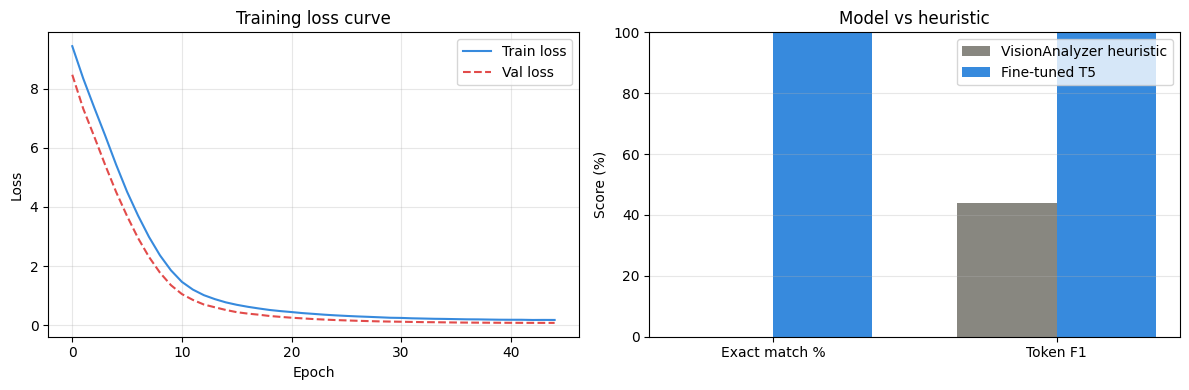

Saved: recall_eval_results.png  ← use this in your LinkedIn post


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='train', color='#378ADD')
axes[0].plot(val_losses,   label='val',   color='#E24B4A', linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# full dataset numbers — test split alone varies too much with n=7
n          = len(RAW_DATASET)
categories = ['Exact match %', 'Token F1 %']
h_scores   = [100*all_correct_heuristic/n, np.mean(heuristic_f1s)*100]
m_scores   = [100*all_correct_model/n,     np.mean(model_f1s)*100]

x, w = np.arange(len(categories)), 0.35
axes[1].bar(x - w/2, h_scores, w, label='VisionAnalyzer heuristic', color='#888780')
axes[1].bar(x + w/2, m_scores, w, label='Fine-tuned flan-t5-small', color='#378ADD')
axes[1].set_title('Full dataset — heuristic vs model')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Score (%)')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('recall_eval_results.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('recall_eval_results.png')

In [10]:
all_correct_model = all_correct_heuristic = 0
model_f1s, heuristic_f1s = [], []

print(f'{"":─<65}')
for ex in RAW_DATASET:
    pred      = predict(ex['tokens'])
    true      = ex['label']
    heuristic = HEURISTIC_LABELS.get(ex['image_id'], 'Memory')

    m = pred.strip().lower()      == true.strip().lower()
    h = heuristic.strip().lower() == true.strip().lower()

    if m: all_correct_model += 1
    if h: all_correct_heuristic += 1
    model_f1s.append(token_f1(pred, true))
    heuristic_f1s.append(token_f1(heuristic, true))

    print(f'  {ex["image_id"]}  {"✅" if m else "❌"} {pred!r:28}  {"✅" if h else "❌"} {heuristic!r}')

n = len(RAW_DATASET)
print(f'{"":─<65}')
print(f'  model     {all_correct_model}/{n} ({100*all_correct_model/n:.1f}%)  f1={np.mean(model_f1s):.3f}')
print(f'  heuristic {all_correct_heuristic}/{n} ({100*all_correct_heuristic/n:.1f}%)  f1={np.mean(heuristic_f1s):.3f}')

  FULL DATASET — model predictions vs heuristic vs ground truth
  park_001  true='Parking · P5 B'           model=✅'Parking · P5 B'           heuristic=❌'Memory'
  park_002  true='Parking · C6'             model=✅'Parking · C6'             heuristic=❌'TO TH'
  park_003  true='Parking · D04'            model=✅'Parking · D04'            heuristic=✅'Parking · D04'
  park_004  true='Parking · D6'             model=✅'Parking · D6'             heuristic=✅'Parking · D6'
  park_005  true='Parking · P6 F'           model=✅'Parking · P6 F'           heuristic=❌'Parking · P6'
  park_006  true='Parking · 8'              model=✅'Parking · 8'              heuristic=❌'00'
  park_007  true='Parking · B2 S20'         model=✅'Parking · B2 S20'         heuristic=❌'Parking · B2'
  park_008  true='Parking · A'              model=✅'Parking · A'              heuristic=❌'Parking · LEVEL ALBL'
  park_009  true='Parking · 68 A'           model=✅'Parking · 68 A'           heuristic=❌'68 A'
  park_010  true='Park

In [11]:
# ── Cell 10: Save model ───────────────────────────────────────────────────────
model.save_pretrained('./recall_parking_model')
tokenizer.save_pretrained('./recall_parking_model')
print('Model saved to ./recall_parking_model')
print('Download this folder — it can be converted to CoreML for on-device use.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./recall_parking_model
Download this folder — it can be converted to CoreML for on-device use.


In [12]:
from google.colab import files
files.download('recall_eval_results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>